<a href="https://colab.research.google.com/github/justleein2/MachineLearning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1:

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Task 2:

In [5]:
display(df.head())

df.info()

df.describe()

features = ["tenure", "MonthlyCharges", "TotalCharges", "Contract", "PaymentMethod"]
display(df[features].head(10))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod
0,1,29.85,29.85,Month-to-month,Electronic check
1,34,56.95,1889.5,One year,Mailed check
2,2,53.85,108.15,Month-to-month,Mailed check
3,45,42.30,1840.75,One year,Bank transfer (automatic)
4,2,70.70,151.65,Month-to-month,Electronic check
5,8,99.65,820.5,Month-to-month,Electronic check
6,22,89.10,1949.4,Month-to-month,Credit card (automatic)
7,10,29.75,301.9,Month-to-month,Mailed check
8,28,104.80,3046.05,Month-to-month,Electronic check
9,62,56.15,3487.95,One year,Bank transfer (automatic)


Task 3:

In [6]:
df = df.drop(columns=['customerID'])

Task 4:

In [7]:
from sklearn.impute import SimpleImputer

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Task 5:

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])




cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

Task 6:

In [15]:
from sklearn.linear_model import SGDClassifier

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))
])

clf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', random_state=42))])

Task 7:


.... split 80/20 ....
confusion matrix:
 [[940  95]
 [208 166]]

classification report:
               precision    recall  f1-score   support

    No churn       0.82      0.91      0.86      1035
       Churn       0.64      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8296

.... split 70/30 ....
confusion matrix:
 [[1388  164]
 [ 259  302]]

classification report:
               precision    recall  f1-score   support

    No churn       0.84      0.89      0.87      1552
       Churn       0.65      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

ROC-AUC: 0.8420

.... split 60/40 ....
confusion matrix:
 [[1763  307]
 [ 291  457]]

classification report:
               precision    recall  f

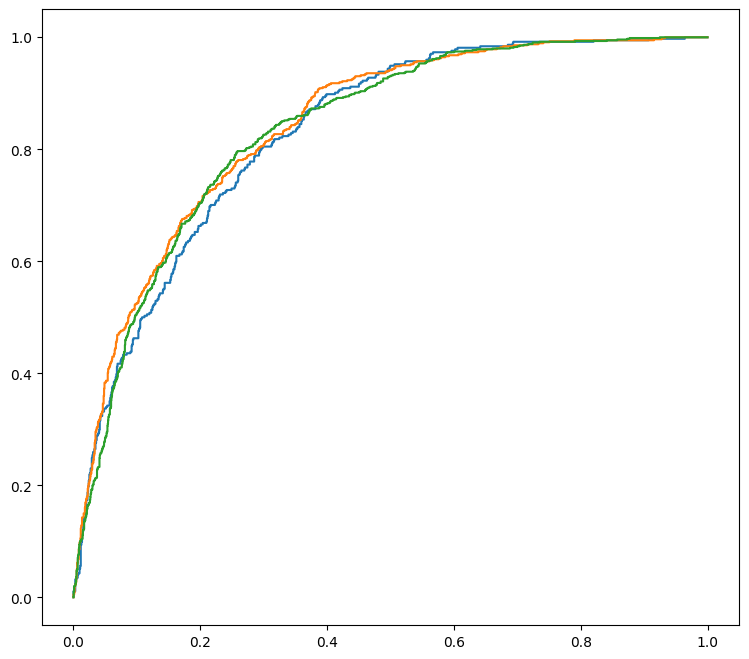

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

splits = [(0.20, "80/20"), (0.30, "70/30"), (0.40, "60/40")]
results = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SGDClassifier(
            loss='log_loss', penalty='l2', alpha=1e-4,
            max_iter=1000, tol=1e-3, random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    results[label] = {
        'model': pipe,
        'auc': auc,
        'y_test': y_test,
        'y_prob': y_prob
    }

    print(f"\n.... split {label} ....")
    print("confusion matrix:\n",  confusion_matrix(y_test, y_pred))

    print("\nclassification report:\n", classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
    print(f"ROC-AUC: {auc:.4f}")

print("\nROC curve:")
plt.figure(figsize=(9, 8))
for label, res in results.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_prob'])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {res['auc']:.4f})")

Task 8:

<Axes: >

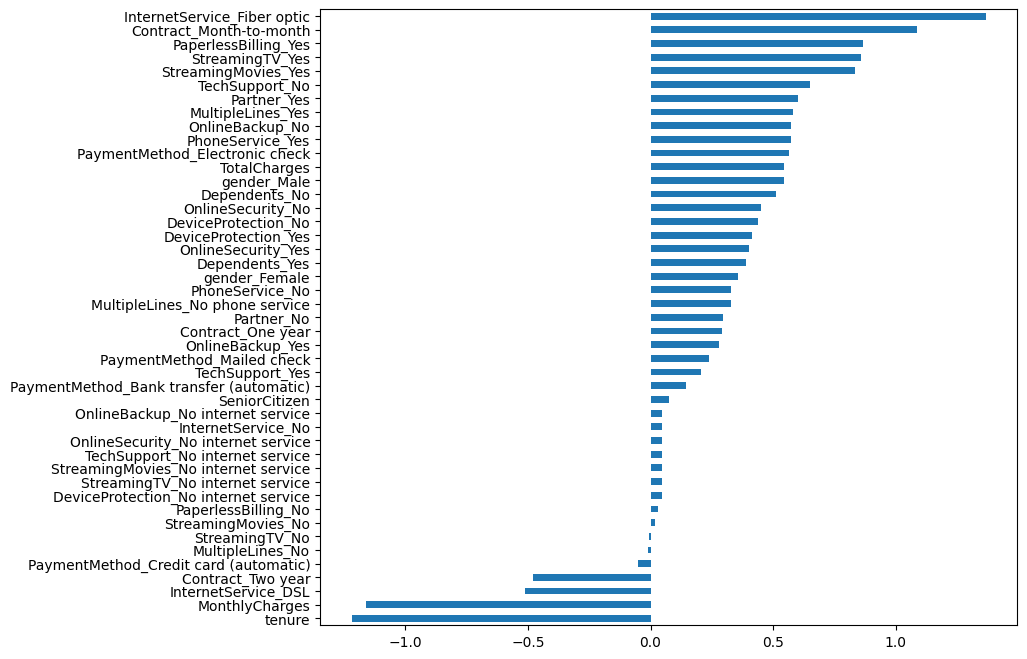

In [66]:
from sklearn.base import clone

best_pipe = results["80/20"]["model"]
pre = best_pipe.named_steps["preprocessor"]
clf = best_pipe.named_steps["classifier"]

cat_feature_names = (
    pre.named_transformers_["cat"]
       .named_steps["onehot"]
       .get_feature_names_out(cat_cols)
       .tolist()
)
feature_names = num_cols + cat_feature_names

coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values()

coefs.plot.barh(figsize=(9, 8))